In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_itc_all = pd.read_csv("data/full-data.csv")

In [3]:
df_itc_all.head()

,Unnamed: 0,right_time,right_val,left_time,left_val,att_check,condition,time_diff,sooner_time,relative_value_diff,absolute_value_diff,right_picked,sid,month
0,0,42,2.666667,21,0.666667,0,4,21,21,4.0,2.0,1,1,March
1,1,0,33.333333,50,133.333333,0,4,50,0,4.0,100.0,0,1,March
2,2,9,1500.000000,7,1000.000000,0,4,2,7,1.5,500.0,1,1,March
3,3,0,1000.000000,1,1100.000000,0,4,1,0,1.1,100.0,0,1,March
4,4,7,50.000000,11,55.000000,0,4,4,7,1.1,5.0,0,1,March


In [38]:
df_itc_all["r-l-v"] = df_itc_all["right_val"] - df_itc_all["left_val"]
df_itc_all["r-l-v-log"] = np.log(df_itc_all["right_val"]) - np.log(df_itc_all["left_val"])
df_itc_all["r-l-t"] = df_itc_all["right_time"] - df_itc_all["left_time"]
np.corrcoef(df_itc_all["r-l-v-log"], df_itc_all["r-l-t"])

array([[1.        , 0.47049261],
       [0.47049261, 1.        ]])

In [46]:
df_plt_v = df_itc_all.groupby("r-l-v-log")["right_picked"].agg(["mean", "count"]).reset_index()
df_plt_t = df_itc_all.groupby("r-l-t")["right_picked"].agg(["mean", "count"]).reset_index()

In [47]:
df_plt_vt = pd.concat([
    df_plt_v.melt(id_vars=["mean", "count"]),
    df_plt_t.melt(id_vars=["mean", "count"])
])

In [50]:
df_itc_all["v>0"] = df_itc_all["r-l-v"] > 0
df_itc_all["t>0"] = df_itc_all["r-l-t"] > 0

In [57]:
np.corrcoef(df_itc_all["v>0"], df_itc_all["t>0"])

array([[1., 1.],
       [1., 1.]])

In [52]:
df_itc_all.groupby("v>0")["right_picked"].mean()

v>0
False    0.175722
True     0.820740
Name: right_picked, dtype: float64

In [53]:
df_itc_all.groupby("t>0")["right_picked"].mean()

t>0
False    0.175722
True     0.820740
Name: right_picked, dtype: float64

/tmp/ipykernel_3897327/171584332.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
/tmp/ipykernel_3897327/171584332.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
/tmp/ipykernel_3897327/171584332.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)


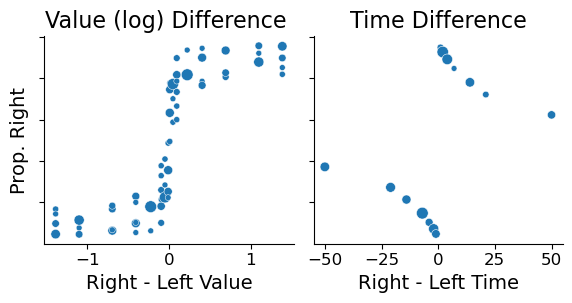

In [121]:
g = sns.FacetGrid(data=df_plt_vt, col="variable", col_wrap=2, sharex=False)
_ = g.map_dataframe(sns.scatterplot, x="value", y="mean", size="count")

titles = ["Value (log) Difference ", "Time Difference"]
xlabs = ["Right - Left Value", "Right - Left Time"]
for idx, ax in enumerate(g.axes.flat):
    ax.set_xlabel(xlabs[idx], fontsize=14)
    ax.set_ylabel("Prop. Right", fontsize=14)
    ax.set_title(titles[idx], fontsize=16)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)

In [110]:
df_itc_all["r-l-t-bin"] = pd.cut(df_itc_all["r-l-t"], bins=[-51, -15, 0, 15, 51])

In [111]:
df_plt_both = df_itc_all.groupby(["r-l-v-log", "r-l-t-bin"])["right_picked"].agg(["mean", "count"]).reset_index()

/tmp/ipykernel_3897327/458380109.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plt_both = df_itc_all.groupby(["r-l-v-log", "r-l-t-bin"])["right_picked"].agg(["mean", "count"]).reset_index()


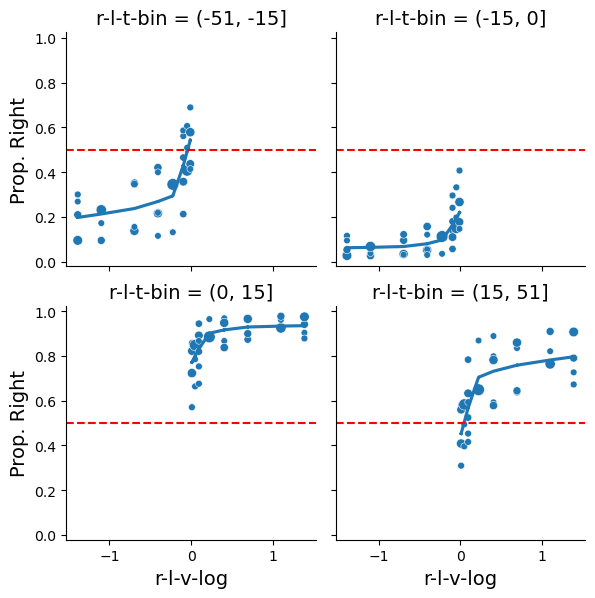

In [124]:
g = sns.FacetGrid(data=df_plt_both, col="r-l-t-bin", col_wrap=2)
g.map_dataframe(sns.scatterplot, x="r-l-v-log", y="mean", size="count")
_ = g.map_dataframe(sns.regplot, x="r-l-v-log", y="mean", scatter=False, lowess=True)

for idx, ax in enumerate(g.axes.flat):
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel("Prop. Right", fontsize=14)
    ax.set_title(ax.get_title(), fontsize=14)

    ax.axhline(y=.5, color="red", linestyle="--")


<Axes: >

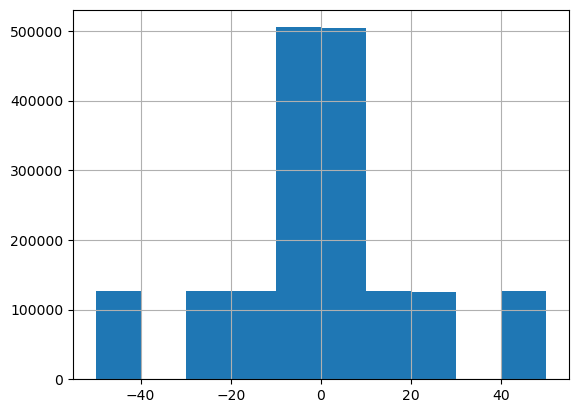

In [119]:
df_itc_all["r-l-t"].hist()